Question 2: Build a recommendation system that can suggest a good next move based on your
current setup. Also include the possibility to return the second- and third best moves. Use a part
of the Lichess database as dataset. Find similar games to predict the next move, based on your
current setup and the history of your game. Possibly include your general playstyle as feature.
What are you going to consider as features? What type of recommendation system are you
going to use? You must also justify your design choices and how different weights are assigned
to different features.

features:
current state of the board (notation?)
history of the board (notation?)
playstyle: beginner / expert => based on elo rating?

type of recommendation system:
content-based: based on similar moves
collaberative: 
=> user-based filtering: playstyle?
=> item-based filtering: similarity between moves (what is the difference between item-based and content-based filtering?)

data processing
remove the timestamps: [%clk 0:01:59]

In [54]:
STOCKFISH_PATH = "/usr/games/stockfish"

In [15]:
%pip install chess
%pip install pandas
%pip install --upgrade numpy>=1.20.3
%pip install scikit-surprise
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.3.5 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.3.5 which is incompatible.
scikit-learn 1.3.1 requires numpy<2.0,>=1.17.3, but you have numpy 2.3.5 which is incompatible.
scipy 1.11.3 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.3.5 which is incompatible.
contourpy 1.1.1 requires numpy<2.0,>=1.16; python_version <= "3.11", but you have numpy 2.3.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requiremen

# Dataset analysis
We downloaded the October 2025 dataset of [Lichess](https://database.lichess.org/standard/lichess_db_standard_rated_2025-10.pgn.zst).

In [36]:
datasetpath = "lichess_dataset/lichess_db_standard_rated_2025-10.pgn/lichess_db_standard_rated_2025-10.pgn"

## Explore the pgn file

In [37]:
# Read and print the first 25 lines of the PGN file without loading the whole file in memory
with open(datasetpath, "r", encoding="utf-8") as f:
    for i in range(25):
        line = f.readline()
        print(line.rstrip())

[Event "Rated Bullet game"]
[Site "https://lichess.org/ql58xxA3"]
[Date "2025.10.01"]
[Round "-"]
[White "Caredcm"]
[Black "vipul1972"]
[Result "1-0"]
[UTCDate "2025.10.01"]
[UTCTime "00:00:08"]
[WhiteElo "1217"]
[BlackElo "1232"]
[WhiteRatingDiff "+6"]
[BlackRatingDiff "-6"]
[ECO "B20"]
[Opening "Sicilian Defense: Bowdler Attack"]
[TimeControl "120+1"]
[Termination "Time forfeit"]

1. e4 { [%clk 0:02:00] } 1... c5 { [%clk 0:02:00] } 2. Bc4 { [%clk 0:02:00] } 2... e6 { [%clk 0:01:59] } 3. d3 { [%clk 0:02:00] } 3... Nc6 { [%clk 0:01:59] } 4. Nc3 { [%clk 0:02:00] } 4... Be7 { [%clk 0:01:59] } 5. Nf3 { [%clk 0:01:57] } 5... a6 { [%clk 0:01:59] } 6. a3 { [%clk 0:01:57] } 6... d6 { [%clk 0:01:59] } 7. Ba2 { [%clk 0:01:55] } 7... Bd7 { [%clk 0:01:59] } 8. Nd2 { [%clk 0:01:48] } 8... Rc8 { [%clk 0:01:58] } 9. Qg4 { [%clk 0:01:48] } 9... Bf6 { [%clk 0:01:51] } 10. Qh5 { [%clk 0:01:39] } 10... Nd4 { [%clk 0:01:43] } 11. Kd1 { [%clk 0:01:34] } 11... Nh6 { [%clk 0:01:29] } 12. Ne2 { [%clk 0:01:28

## filter evaluated games to a different file

About 6% of the games include [Stockfish](https://chessify.me/blog/chess-engine-evaluation) analysis evaluations: [%eval 2.35] (235 centipawn advantage), [%eval #-4] (getting mated in 4), always from White's point of view.
The WhiteElo and BlackElo tags contain Glicko2 ratings.
Games contain clock information down to the second as PGN %clk comments since April 2017. If you need centisecond precision, there is a separate export of games across all chess variants and time controls from 2013 to 2021 using %clkc comments.
Players using the Bot API are marked with [WhiteTitle "BOT"] or [BlackTitle "BOT"], respectively.
Variant games have a Variant tag, e.g., [Variant "Antichess"]. 

=> Only keep the games that have stockfish analysis evaluations.

In [ ]:
import re

def filter_games_with_eval(input_path, output_path):
    result_pattern = re.compile(r"\s*(1-0|0-1|1/2-1/2)\s*$")
    eval_pattern = re.compile(r"\[%eval")
    current_game = []
    has_eval = False

    with open(input_path, "r", encoding="utf-8") as infile, open(output_path, "w", encoding="utf-8") as outfile:
        for line in infile:
            current_game.append(line)
            if eval_pattern.search(line):
                has_eval = True
            if result_pattern.search(line):
                if has_eval:
                    outfile.write("".join(current_game))
                    outfile.write("\n\n")  # Separate games
                current_game = []
                has_eval = False

# Usage
filter_games_with_eval(
    input_path="lichess_dataset/lichess_db_standard_rated_2025-10.pgn/lichess_db_standard_rated_2025-10.pgn",
    output_path="lichess_dataset/evaluated_games.pgn"
)

In [38]:
datasetpath = "lichess_dataset/evaluated_games.pgn"

In [39]:
# Read and print only the PGN moves of the first 5 entries (games) from the file
import re

entries = []
current_entry = []
result_pattern = re.compile(r"\s*(1-0|0-1|1/2-1/2)\s*$")

with open(datasetpath, "r", encoding="utf-8") as f:
    for line in f:
        current_entry.append(line)
        if result_pattern.search(line):
            entries.append("".join(current_entry))
            current_entry = []
            if len(entries) == 5:
                break

def extract_pgn_moves(entry):
    lines = entry.splitlines()
    moves = []
    for line in lines:
        if not line.startswith("[") and line.strip():
            moves.append(line.strip())
    return " ".join(moves)

for i, entry in enumerate(entries, 1):
    moves = extract_pgn_moves(entry)
    print(f"Entry {i} moves:\n{moves}\n{'-'*40}")

Entry 1 moves:
1. e4 { [%eval 0.18] [%clk 0:01:00] } 1... d5 { [%eval 0.54] [%clk 0:01:00] } 2. exd5 { [%eval 0.51] [%clk 0:01:00] } 2... Nf6 { [%eval 0.53] [%clk 0:00:59] } 3. Nc3 { [%eval 0.1] [%clk 0:01:00] } 3... e6?! { [%eval 0.84] [%clk 0:00:59] } 4. dxe6 { [%eval 0.86] [%clk 0:00:59] } 4... Bxe6 { [%eval 0.88] [%clk 0:00:59] } 5. Bb5+ { [%eval 0.62] [%clk 0:00:58] } 5... c6 { [%eval 0.64] [%clk 0:00:59] } 6. Ba4 { [%eval 0.33] [%clk 0:00:58] } 6... b5? { [%eval 1.43] [%clk 0:00:58] } 7. Bb3 { [%eval 1.54] [%clk 0:00:58] } 7... Bxb3 { [%eval 1.43] [%clk 0:00:57] } 8. axb3 { [%eval 1.53] [%clk 0:00:58] } 8... Qe7+ { [%eval 1.9] [%clk 0:00:57] } 9. Qe2 { [%eval 1.83] [%clk 0:00:56] } 9... Qxe2+ { [%eval 1.89] [%clk 0:00:57] } 10. Ngxe2 { [%eval 1.53] [%clk 0:00:56] } 10... Bc5 { [%eval 1.96] [%clk 0:00:55] } 11. d4 { [%eval 1.53] [%clk 0:00:55] } 11... Bb4?! { [%eval 2.29] [%clk 0:00:53] } 12. Bd2 { [%eval 1.74] [%clk 0:00:52] } 12... Bxc3?! { [%eval 2.65] [%clk 0:00:53] } 13. bxc3

### Convert pgn file to a dataframe

In [ ]:
import re
import pandas as pd

def pgn_game_generator(filepath):
    result_pattern = re.compile(r"\s*(1-0|0-1|1/2-1/2)\s*$")
    current_game = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            current_game.append(line)
            if result_pattern.search(line):
                yield "".join(current_game)
                current_game = []

def extract_headers_and_moves(game):
    headers = {}
    moves = []
    evals = []
    for line in game.splitlines():
        if line.startswith('['):
            key_value = re.match(r'\[(\w+) "(.*)"\]', line)
            if key_value:
                key, value = key_value.groups()
                headers[key] = value
        elif line.strip():
            moves.append(line.strip())
            eval_match = re.findall(r'\[%eval ([^\]]+)\]', line)
            evals.extend(eval_match)
    return headers, " ".join(moves), evals

# Stream parse and build DataFrame in chunks
rows = []
for i, game in enumerate(pgn_game_generator("lichess_dataset/evaluated_games.pgn")):
    headers, moves, evals = extract_headers_and_moves(game)
    row = headers.copy()
    row['moves'] = moves
    row['evals'] = evals
    row['game_id'] = i
    rows.append(row)
    if (i+1) % 10000 == 0:
        print(f"Processed {i+1} games")
        # Optionally: write chunk to disk and clear rows to save memory
        pd.DataFrame(rows).to_csv(f"lichess_dataset/evaluated_dataframes/chunk_{i//10000}.csv")
        rows = []

df = pd.DataFrame(rows)
df.head()

# Dataset preprocessing
We take the first 10 000 evaluated games as a first set to train on.

In [1]:
import pandas as pd
df = pd.read_csv("lichess_dataset/evaluated_dataframes/chunk_0.csv")

In [35]:
df.head()

,Unnamed: 0,Event,Site,Date,Round,White,Black,Result,UTCDate,UTCTime,...,BlackRatingDiff,ECO,Opening,TimeControl,Termination,moves,evals,game_id,BlackTitle,WhiteTitle
0,0,Rated Bullet game,https://lichess.org/J7qpGjym,2025.10.01,-,HiteshMadras,BearBrand,1-0,2025.10.01,00:00:08,...,-5.0,B01,Scandinavian Defense: Modern Variation,60+0,Normal,1. e4 { [%eval 0.18] [%clk 0:01:00] } 1... d5 ...,"['0.18', '0.54', '0.51', '0.53', '0.1', '0.84'...",0,NaN,NaN
1,1,Rated Rapid game,https://lichess.org/UzIKiHzx,2025.10.01,-,JuanEsley,Deeibid,0-1,2025.10.01,00:00:11,...,6.0,C00,French Defense: King's Indian Attack,600+0,Normal,1. e4 { [%eval 0.18] [%clk 0:10:00] } 1... e6 ...,"['0.18', '0.3', '0.0', '0.0', '0.0', '0.0', '-...",1,NaN,NaN
2,2,Rated Blitz game,https://lichess.org/RvR8cMJD,2025.10.01,-,LeandroCordeiro,fallacious_legacy,0-1,2025.10.01,00:00:11,...,5.0,A24,"English Opening: King's English Variation, Two...",180+2,Normal,1. c4 { [%eval 0.12] [%clk 0:03:00] } 1... Nf6...,"['0.12', '0.14', '0.12', '0.18', '0.07', '0.39...",2,NaN,NaN
3,3,Rated Blitz game,https://lichess.org/ochaHozz,2025.10.01,-,Raimiusa,G3m2s,1-0,2025.10.01,00:00:11,...,-5.0,D02,Queen's Pawn Game: Zukertort Variation,180+2,Normal,1. d4 { [%eval 0.17] [%clk 0:03:00] } 1... d5 ...,"['0.17', '0.18', '0.08', '0.19', '0.03', '0.25...",3,NaN,NaN
4,4,Rated Blitz game,https://lichess.org/wDuQ3fW3,2025.10.01,-,vladimir_bg,ruso0504,1-0,2025.10.01,00:00:11,...,-5.0,D94,Grünfeld Defense: Makogonov Variation,180+2,Time forfeit,1. d4 { [%eval 0.17] [%clk 0:03:00] } 1... Nf6...,"['0.17', '0.19', '0.18', '0.28', '0.18', '0.28...",4,NaN,NaN


# Collaborative Filtering: Single Value Decomposition

## Build the dataset
* use the fenboard notation of a chessboard as the user
* use the move as the item
* use the change in stockfish evaluation score of the board as the rating

In [56]:
import pandas as pd
df = pd.read_csv("lichess_dataset/evaluated_dataframes/chunk_0.csv")

In [79]:
df.tail()

,Unnamed: 0,Event,Site,Date,Round,White,Black,Result,UTCDate,UTCTime,...,BlackRatingDiff,ECO,Opening,TimeControl,Termination,moves,evals,game_id,BlackTitle,WhiteTitle
9995,9995,Rated Rapid game,https://lichess.org/KmeN6MnB,2025.10.01,-,Oshrussia,AdiKathu,1-0,2025.10.01,01:37:33,...,-3.0,C50,"Italian Game: Giuoco Pianissimo, Italian Four ...",600+5,Normal,1. e4 { [%eval 0.18] [%clk 0:10:00] } 1... e5 ...,"['0.18', '0.22', '0.03', '0.11', '-0.45', '1.2...",9995,NaN,NaN
9996,9996,Rated Blitz game,https://lichess.org/Ctn89rPy,2025.10.01,-,OTB_Red_Baron,AchZeitnot,0-1,2025.10.01,01:37:34,...,6.0,B30,Sicilian Defense: Old Sicilian,180+2,Normal,1. e4 { [%eval 0.18] [%clk 0:03:00] } 1... c5 ...,"['0.18', '0.24', '0.2', '0.3', '0.19', '0.41',...",9996,NaN,NaN
9997,9997,Rated Rapid game,https://lichess.org/QhyH9jYY,2025.10.01,-,timdelacy,tyndale,0-1,2025.10.01,01:37:34,...,5.0,D01,Rapport-Jobava System,600+0,Normal,1. d4 { [%eval 0.17] [%clk 0:10:00] } 1... Nf6...,"['0.17', '0.19', '-0.02', '0.0', '-0.1', '0.0'...",9997,NaN,NaN
9998,9998,Rated Rapid game,https://lichess.org/YUzPdhkc,2025.10.01,-,Sanjay220,Aurelionix,0-1,2025.10.01,01:37:34,...,7.0,C26,Vienna Game: Stanley Variation,600+0,Time forfeit,1. e4 { [%eval 0.18] [%clk 0:10:00] } 1... e5 ...,"['0.18', '0.22', '0.08', '0.03', '0.0', '0.8',...",9998,NaN,NaN
9999,9999,Rated Blitz game,https://lichess.org/zQhopyuM,2025.10.01,-,bishopthingy,Jjjkk-13949,1-0,2025.10.01,01:37:35,...,NaN,B01,"Scandinavian Defense: Valencian Variation, Mai...",180+0,Normal,1. e4 { [%eval 0.18] [%clk 0:03:00] } 1... d5 ...,"['0.18', '0.54', '0.51', '0.52', '0.47', '0.66...",9999,NaN,NaN


### Scoring
* In the first version of the rating, we didn't take into account that stockfish always evaluates from the White side. Black’s moves often bounced the king between e8 and e7 for example. To solve for this we flipped the score if it was Black's turn.
* We set the change in score as the rating instead of the current score of the board, because that tells us more about the move.

In [94]:
import chess.pgn
import numpy as np
import io
import re

def parse_eval_score(eval_str):
    if eval_str is None:
        return None
    if eval_str.startswith('#'):
        try:
            return 100 if eval_str[1] != '-' else -100
        except:
            return None
    try:
        return float(eval_str)
    except:
        return None

def expand_df(df):   
    encoded_rows = [] 
    for idx, row in df.iterrows():
        moves_str = row['moves']
        # Create a PGN string for this game
        pgn_str = moves_str
        # Use python-chess PGN parser to parse moves
        game = chess.pgn.read_game(io.StringIO(pgn_str))
        if game is None:
            continue
        board = game.board()
        node = game
        previous_score = 0
        while node.variations:
            move = node.variation(0).move
            node = node.variation(0)
            # remove the halfmove clock and full move number from the fen notation
            fenboard = ' '.join(board.fen().split(' ')[0:4])
            board.push(move)     
            # Extract Stockfish evaluation from comment
            eval_score = None        
            if node.comment:
                match = re.search(r'\[%eval ([^\]]+)\]', node.comment)
                if match:
                    eval_score = match.group(1)
            score = parse_eval_score(eval_score)
            # skip if no valid numeric score
            if score is None:
                continue

            # compute change only when previous_score exists
            if previous_score is None:
                score_change = None
            else:
                score_change = score - previous_score

            encoded_rows.append({
                'board': fenboard,
                'move': move.uci() if move else None,
                'score': score_change if board.turn == chess.WHITE else -score_change
            })
            previous_score = score


    expanded_df = pd.DataFrame(encoded_rows)
    # remove rows where eval_score is NaN
    expanded_df = expanded_df.dropna(subset=['score'])

    return expanded_df

In [95]:
expanded_df = expand_df(df)

illegal san: 'e4' in r2q1rk1/pppb1pb1/3p1npp/8/2PNP3/2N2P2/PP2K1PP/R1Q4R b - - 2 14 while parsing <Game at 0x7f5c4711ce10 ('?' vs. '?', '????.??.??' at '?')>


In [96]:
expanded_df.tail()

,board,move,score
649704,2r2rkb/1p3p1p/p5pP/3R2P1/3B4/P2Q4/1P3P2/1K6 b - -,f8e8,1.55
649705,2r1r1kb/1p3p1p/p5pP/3R2P1/3B4/P2Q4/1P3P2/1K6 w...,d4h8,0.53
649706,2r1r1kB/1p3p1p/p5pP/3R2P1/8/P2Q4/1P3P2/1K6 b - -,g8h8,91.24
649707,2r1r2k/1p3p1p/p5pP/3R2P1/8/P2Q4/1P3P2/1K6 w - -,d3d4,0.00
649708,2r1r2k/1p3p1p/p5pP/3R2P1/3Q4/P7/1P3P2/1K6 b - -,h8g8,0.00


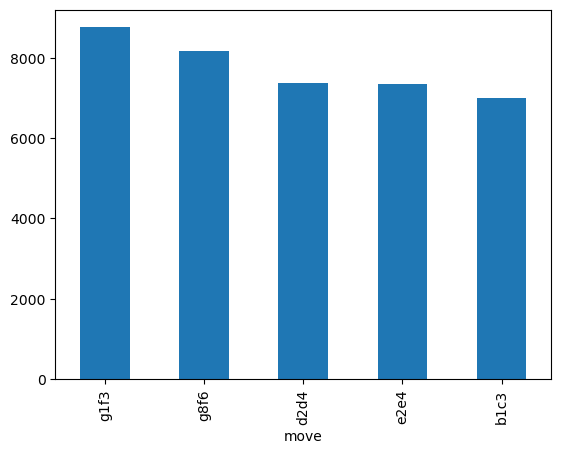

In [84]:
# make a bar plot of the 5 most popular moves
import matplotlib.pyplot as plt
plt = expanded_df['move'].value_counts().head(5).plot(kind='bar')

In [86]:
# the most popular move is g1f3. what is a possible position where this move is played?
position_of_most_popular_moves = expanded_df[expanded_df['move'] == 'g1f3'].head()
position_of_most_popular_moves

,board,move,score
126,rnbqkbnr/pp3ppp/4p3/2pp4/4P3/3P4/PPPN1PPP/R1BQ...,g1f3,0.02
255,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,g1f3,0.10
315,rnbqk2r/ppp1ppbp/5np1/3p4/2PP4/2N1P3/PP3PPP/R1...,g1f3,0.10
386,rnbqkb1r/pppppppp/5n2/8/3P4/8/PPP1PPPP/RNBQKBN...,g1f3,0.08
447,rnbqkbnr/pp1ppppp/8/2p5/4P3/8/PPPP1PPP/RNBQKBN...,g1f3,0.04


In [87]:
# visualize the position
import chess
board = chess.Board(position_of_most_popular_moves.iloc[0]['board'])
print(board)
# the most popular move is moving the knight from its starting place towards the middle.

r n b q k b n r
p p . . . p p p
. . . . p . . .
. . p p . . . .
. . . . P . . .
. . . P . . . .
P P P N . P P P
R . B Q K B N R


## Grid search the svd

In [81]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import GridSearchCV

df_for_surprise = expanded_df[['board', 'move', 'score']].copy()
df_for_surprise = df_for_surprise.dropna()

# Define the reader with the correct rating scale
reader = Reader(rating_scale=(df_for_surprise['score'].min(), df_for_surprise['score'].max()))

# Load the data into Surprise format (order: user, item, rating)
data = Dataset.load_from_df(df_for_surprise[['board', 'move', 'score']], reader)
param_grid = {
    "n_epochs": [5, 10, 15, 20], 
    "lr_all": [0.0001, 0.001, 0.002, 0.005], 
    "reg_all": [0.1, 0.2, 0.4, 0.6],
    }
gs = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3)
gs.fit(data)

# best RMSE score
print(gs.best_score["rmse"])

# combination of parameters that gave the best RMSE score
print(gs.best_params["rmse"])

13.46735572536528
{'n_epochs': 10, 'lr_all': 0.001, 'reg_all': 0.2}


## Train the svd

In [97]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

# Prepare the ratings DataFrame with board as "user", move as "item", score as "rating"
df_for_surprise = expanded_df[['board', 'move', 'score']].copy()
df_for_surprise = df_for_surprise.dropna()

# Define the reader with the correct rating scale
reader = Reader(rating_scale=(df_for_surprise['score'].min(), df_for_surprise['score'].max()))

# Load the data into Surprise format (order: user, item, rating)
data = Dataset.load_from_df(df_for_surprise[['board', 'move', 'score']], reader)

# Apply SVD and cross-validate
svd = SVD(n_epochs = 10, lr_all= 0.001, reg_all= 0.2)
results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    13.2073 13.5683 13.4427 13.5284 13.5848 13.4663 0.1385  
MAE (testset)     3.7830  3.8488  3.8367  3.8412  3.8534  3.8326  0.0255  
Fit time          3.97    3.57    3.92    3.72    3.98    3.83    0.16    
Test time         0.44    0.44    0.44    1.25    0.43    0.60    0.33    


## Prediction method

Our recommendation method will check all current legal moves of the board and take the one with the highest recommendation score from the SVD we trained. This resulted in all our matches being draws. We then filtered out immediate 3‑fold and five‑fold repetition because these lead to draws. This still resulted in a lot of draws and very long running matches. We then added some randomness to the selection of the next move: ~60% for best, ~30% for second, ~10% for third. This resulted in winning a few matches both against ourselves and against stockfish (on an easy setting = ELO 1350).

In [127]:
def make_move(board, debug=False, avoid_repetition=True):
    import random
    if isinstance(board, chess.Board):
        board_obj = board
        fen = board_obj.fen()
    else:
        board_obj = chess.Board(board)
        fen = board

    legal_moves = list(board_obj.legal_moves)
    if not legal_moves:
        return None

    move_scores = []
    for move in legal_moves:
        pred = svd.predict(fen, move.uci())
        move_scores.append((move, pred.est))

    # sort by predicted score descending
    move_scores.sort(key=lambda x: x[1], reverse=True)

    # take up to 3 best moves (preserve order)
    top_candidates = [m for m, _ in move_scores[:3]]

    # avoid immediate repetition for candidates
    filtered = []
    for mv in top_candidates:
        if avoid_repetition:
            bc = board_obj.copy()
            bc.push(mv)
            if bc.is_repetition(3) or bc.is_fivefold_repetition():
                continue
        filtered.append(mv)

    # fallback if none remain after filtering
    if not filtered:
        return top_candidates[0] if top_candidates else legal_moves[0]

    # pick move: rand 0-10, if <1 pick 3rd, if <4 pick 2nd, else pick 1st
    rand = random.randint(0, 10)
    if rand < 1 and len(filtered) > 2:
        chosen = filtered[2]
    elif rand < 4 and len(filtered) > 1:
        chosen = filtered[1]
    else:
        chosen = filtered[0]

    if debug:
        print("Top3:", [(m.uci(), round(s,3)) for m,s in move_scores[:3]])
        print("Filtered:", [m.uci() for m in filtered], "chosen:", chosen.uci())

    return chosen

## Test against self

In [128]:
num_games = 100
results = {"1-0": 0, "0-1": 0, "1/2-1/2": 0}
debug = True
if(num_games > 1): debug = False
for i in range(num_games):
    board = chess.Board()
    while not board.is_game_over():
        move = make_move(board, debug)
        board.push(move)
    result = board.result()
    results[result] += 1
    if (i+1) % 50 == 0:
        print(f"Game {i+1}/{num_games} finished. Current results: {results}")

print(f"Final results after {num_games} games:")
print(results)

Game 50/100 finished. Current results: {'1-0': 3, '0-1': 2, '1/2-1/2': 45}
Game 100/100 finished. Current results: {'1-0': 7, '0-1': 5, '1/2-1/2': 88}
Final results after 100 games:
{'1-0': 7, '0-1': 5, '1/2-1/2': 88}


## Test against stockfish

In [70]:
import chess

num_games = 100
results = {"1-0": 0, "0-1": 0, "1/2-1/2": 0}
debug = True
if(num_games > 1): debug = False
for i in range(num_games):
    board = chess.Board()
    while not board.is_game_over():
        move = make_move(board, False)
        board.push(move)
    result = board.result()
    results[result] += 1
    if (i+1) % 50 == 0:
        print(f"Game {i+1}/{num_games} finished. Current results: {results}")

print(f"Final results after {num_games} games:")
print(results)

Game 50/100 finished. Current results: {'1-0': 6, '0-1': 2, '1/2-1/2': 42}
Game 100/100 finished. Current results: {'1-0': 10, '0-1': 2, '1/2-1/2': 88}
Final results after 100 games:
{'1-0': 10, '0-1': 2, '1/2-1/2': 88}


# Testing 
from https://surprise.readthedocs.io/en/stable/getting_started.html

## on the testset

In [100]:
## Read data from chunk1
test_df = pd.read_csv("lichess_dataset/evaluated_dataframes/chunk_1.csv")
test_expanded_df = expand_df(test_df)


In [101]:
test_expanded_df.tail()

,board,move,score
651115,r5k1/p1p2ppp/2p5/3P2b1/8/2N4P/PPP2PP1/4R1K1 b - -,c6d5,1.48
651116,r5k1/p1p2ppp/8/3p2b1/8/2N4P/PPP2PP1/4R1K1 w - -,c3d5,-0.17
651117,r5k1/p1p2ppp/8/3N2b1/8/7P/PPP2PP1/4R1K1 b - -,a8b8,0.21
651118,1r4k1/p1p2ppp/8/3N2b1/8/7P/PPP2PP1/4R1K1 w - -,d5c7,1.06
651119,1r4k1/p1N2ppp/8/6b1/8/7P/PPP2PP1/4R1K1 b - -,b8b2,98.43


In [102]:
df_test_ratings = test_expanded_df[['board', 'move', 'score']].copy()
df_test_ratings = df_test_ratings.dropna()
test_data = Dataset.load_from_df(df_test_ratings[['board', 'move', 'score']], reader)

In [103]:
from surprise import accuracy
test_data_raw = df_test_ratings[['board', 'move', 'score']].values.tolist()
predictions = svd.test(test_data_raw)
accuracy_rmse = accuracy.rmse(predictions)
accuracy_mae = accuracy.mae(predictions)

RMSE: 13.2162
MAE:  3.7510
